<h1 style="color:#56B4E9;">Week 5 - Day 2</h1>

<h2 style="color:#0072B2;">DBSCAN & Hierarchical Clustering</h2>

<h3 style="color:#009E73;">Comparing Different Ways to Discover Patient Profiles</h3>

In Day 1, K-Means was applied to the Cleveland Heart Disease dataset to discover patient profiles without using the diagnosis target.

The final model used two clusters, but its Silhouette Score was only **0.232**, indicating that the discovered groups were broad and partially overlapping.

This raises an important question:

**Is the patient structure better represented by a clustering method that does not depend on centroids or assume round clusters?**

In this notebook, the same patients, features, and preprocessing decisions will be used to ensure a fair comparison between:

- K-Means clustering.
- DBSCAN density-based clustering.
- Hierarchical clustering.

The workflow will include:

- Examining the limitations of K-Means.
- Understanding how DBSCAN identifies dense regions and noise.
- Investigating the effect of `eps` and `min_samples`.
- Building and interpreting a hierarchical-clustering dendrogram.
- Comparing all three methods on the same standardized data.
- Selecting the method that best represents this dataset's observed structure.

<span style="color:#009E73;"><b>Main goal:</b></span>  
Determine whether DBSCAN or hierarchical clustering provides a more meaningful representation of the patient data than the two broad and overlapping K-Means clusters found in Day 1.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

In [9]:
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

data = pd.read_csv(
    "../../processed.cleveland.data",
    header=None,
    names=column_names
)

data = data.replace("?", np.nan)

data["ca"] = pd.to_numeric(data["ca"], errors="coerce")
data["thal"] = pd.to_numeric(data["thal"], errors="coerce")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<h2 style="color:#0072B2;">Keeping the Comparison Fair</h2>

The purpose of Day 2 is to compare clustering algorithms rather than compare different feature-selection or preprocessing decisions.

Therefore, the same six features used in Day 1 will be retained:

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`
- `ca`

The same missing-value and scaling procedures will also be applied.

This ensures that differences in the results are caused primarily by the clustering methods rather than by changes to the input data.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Keep the Day 1 feature set, median imputation, and standardization unchanged so that K-Means, DBSCAN, and hierarchical clustering receive the same patient representation.

In [10]:
clustering_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

X = data[clustering_features].copy()

imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

print("Clustering data shape:", X_scaled.shape)
print("Missing values remaining:", X_scaled.isna().sum().sum())

X_scaled.describe().loc[["mean", "std"]].round(2)

Clustering data shape: (303, 6)
Missing values remaining: 0


,age,trestbps,chol,thalach,oldpeak,ca
mean,-0.0,0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


<h2 style="color:#0072B2;">Why K-Means May Not Be Enough</h2>

K-Means represents every cluster using a centroid and assigns each observation to its nearest centroid.

This approach is efficient, but it introduces several important assumptions and limitations.

### 1. The Number of Clusters Must Be Chosen in Advance

K-Means cannot discover the number of clusters automatically.

In Day 1, the Elbow Method and Silhouette Score were needed before selecting \(k=2\).

### 2. Every Patient Must Belong to a Cluster

K-Means has no explicit concept of noise or outliers.

Even a patient located far from both centroids must still be assigned to the nearest cluster. Such observations may also pull a centroid away from the main concentration of patients.

### 3. Clusters Are Separated by Distance from Centroids

K-Means works best when clusters are approximately compact, round, and similarly distributed around their centroids.

It may produce misleading divisions when the natural groups have irregular shapes or different densities.

### 4. Weak Separation Can Still Produce a Complete Partition

The final Day 1 model assigned all 303 patients to one of two clusters, even though its Silhouette Score was only 0.232.

This means K-Means always produced a complete answer, but that answer did not necessarily represent strongly separated patient groups.

<span style="color:#009E73;"><b>Key question:</b></span>  
Can a density-based method identify concentrated patient groups while leaving unusual or isolated patients unassigned?

<h2 style="color:#0072B2;">DBSCAN: Clustering by Density</h2>

DBSCAN takes a different approach from K-Means.

Instead of representing each cluster using a centroid, it searches for regions where observations are densely packed and separates them from sparse regions.

DBSCAN uses two main parameters:

- `eps`: the maximum distance within which observations are considered neighbors.
- `min_samples`: the minimum number of observations, including the point itself, required to form a dense region.

Based on the local density, DBSCAN identifies three types of observations:

### Core Point

A point with at least `min_samples` observations inside its `eps` neighborhood.

Core points form the dense interior of a cluster.

### Border Point

A point that does not have enough neighbors to be a core point but lies inside the neighborhood of another core point.

It belongs to the cluster but is located near its boundary.

### Noise Point

A point that is neither a core point nor reachable from one.

Scikit-learn assigns noise points the label `-1`.

<span style="color:#009E73;"><b>Key difference:</b></span>  
K-Means forces every patient into a predefined number of clusters, while DBSCAN discovers dense groups automatically and can leave isolated patients labeled as noise.

<h2 style="color:#0072B2;">How DBSCAN Parameters Change the Result</h2>

The DBSCAN result depends strongly on the relationship between `eps` and `min_samples`.

### Effect of eps

A very small `eps` creates small neighborhoods.

Few observations can reach each other, so DBSCAN may label much of the dataset as noise or split it into many small clusters.

A very large `eps` connects increasingly distant observations.

Separate dense regions may merge until most or all observations form one cluster.

### Effect of min_samples

A smaller `min_samples` value makes it easier to form a dense region, but weak or accidental groupings may be accepted as clusters.

A larger value requires stronger local density, which can produce more reliable clusters but may classify more observations as noise.

<span style="color:#D55E00;"><b>Important:</b></span>  
The values `eps=0.5` and `min_samples=5` will be used only as an initial baseline. Their result must be examined before selecting the final DBSCAN configuration.

In [11]:
dbscan_initial = DBSCAN(
    eps=0.5,
    min_samples=5
)

initial_dbscan_labels = dbscan_initial.fit_predict(X_scaled)

label_counts = (
    pd.Series(initial_dbscan_labels, name="label")
    .value_counts()
    .sort_index()
)

print("Points per label:")
print(label_counts)

Points per label:
label
-1    303
Name: count, dtype: int64


In [12]:
unique_labels = set(initial_dbscan_labels)

n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = np.sum(initial_dbscan_labels == -1)
noise_percentage = (n_noise / len(initial_dbscan_labels)) * 100

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
print(f"Noise percentage: {noise_percentage:.1f}%")

Number of clusters: 0
Number of noise points: 303
Noise percentage: 100.0%


<h2 style="color:#0072B2;">Interpreting the Initial DBSCAN Result</h2>

With `eps=0.5` and `min_samples=5`, DBSCAN labeled all 303 patients as noise and discovered zero clusters.

This does not indicate a coding error.

Instead, it means that a radius of 0.5 in the six-dimensional standardized feature space was too small for any patient to have enough nearby observations to become a core point.

Because no core points were created:

- No dense region could begin.
- No border points could attach to a dense region.
- Every patient received the noise label `-1`.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Do not accept the initial parameters. Estimate a more appropriate neighborhood radius from the actual distribution of distances between patients.

In [13]:
min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

fifth_neighbor_distances = distances[:, -1]
sorted_distances = np.sort(fifth_neighbor_distances)

print("First 10 sorted distances:")
print(np.round(sorted_distances[:10], 3))

print("\nLast 10 sorted distances:")
print(np.round(sorted_distances[-10:], 3))

First 10 sorted distances:
[0.581 0.616 0.636 0.636 0.642 0.643 0.661 0.661 0.672 0.696]

Last 10 sorted distances:
[2.397 2.436 2.465 2.589 2.722 2.858 2.92  2.921 3.458 4.31 ]


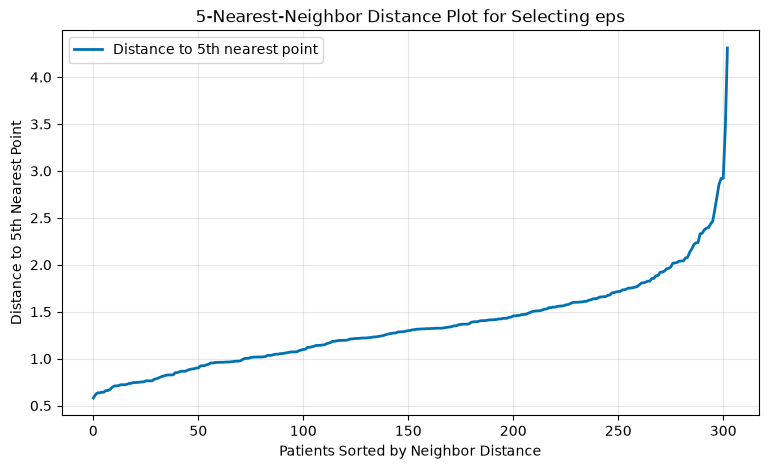

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(len(sorted_distances)),
    sorted_distances,
    color="#0072B2",
    linewidth=2,
    label="Distance to 5th nearest point"
)

plt.xlabel("Patients Sorted by Neighbor Distance")
plt.ylabel("Distance to 5th Nearest Point")
plt.title("5-Nearest-Neighbor Distance Plot for Selecting eps")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

<h2 style="color:#0072B2;">Estimating eps from Neighbor Distances</h2>

The 5-nearest-neighbor distance plot shows a gradual increase across most patients, followed by a noticeably steeper rise near the end.

The transition appears approximately between distances of 1.8 and 2.1.

Distances beyond this region mainly represent a small number of increasingly isolated patients. Selecting an `eps` value near the maximum distance would connect these unusual observations and could hide meaningful noise.

Because the elbow is not perfectly sharp, a single value should not be selected from visual inspection alone.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Compare several `eps` values around the apparent elbow while keeping `min_samples=5` fixed.

In [15]:
eps_values = [1.6, 1.8, 2.0, 2.2]

dbscan_results = []

for eps in eps_values:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = dbscan.fit_predict(X_scaled)
    unique_labels = set(labels)
    
    n_clusters = (
        len(unique_labels)
        - (1 if -1 in unique_labels else 0)
    )
    
    n_noise = np.sum(labels == -1)
    noise_percentage = (n_noise / len(labels)) * 100
    
    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df.round(2)

,eps,clusters,noise_points,noise_percentage
0,1.6,1,34,11.22
1,1.8,1,18,5.94
2,2.0,1,11,3.63
3,2.2,1,9,2.97


In [16]:
dbscan_results = []

for eps in eps_values:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = dbscan.fit_predict(X_scaled)
    unique_labels = set(labels)
    
    n_clusters = (
        len(unique_labels)
        - (1 if -1 in unique_labels else 0)
    )
    
    noise_mask = labels == -1
    n_noise = noise_mask.sum()
    noise_percentage = (n_noise / len(labels)) * 100
    
    score = np.nan
    
    if n_clusters >= 2:
        non_noise_data = X_scaled.loc[~noise_mask]
        non_noise_labels = labels[~noise_mask]
        
        score = silhouette_score(
            non_noise_data,
            non_noise_labels
        )
    
    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage,
        "silhouette_non_noise": score
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df.round(3)

,eps,clusters,noise_points,noise_percentage,silhouette_non_noise
0,1.6,1,34,11.221,NaN
1,1.8,1,18,5.941,NaN
2,2.0,1,11,3.630,NaN
3,2.2,1,9,2.970,NaN


<h2 style="color:#0072B2;">What Does One DBSCAN Cluster Mean?</h2>

Across the tested `eps` values from 1.6 to 2.2, DBSCAN consistently discovered one dense cluster.

As `eps` increased, more patients became connected to this dense region and the number of noise points decreased:

- At `eps=1.6`, 34 patients were labeled as noise.
- At `eps=2.2`, only 9 patients remained noise.

However, no second density-separated cluster appeared.

The Silhouette Score could not be calculated because it requires at least two clusters. Noise points labeled `-1` are not treated as a second cluster.

This result reveals an important difference between the methods:

- K-Means was instructed to divide the data into two groups.
- DBSCAN was allowed to discover the density structure without a predefined cluster count.
- DBSCAN currently suggests that most patients belong to one connected dense region rather than two clearly separated density regions.

<span style="color:#D55E00;"><b>Next check:</b></span>  
Inspect smaller `eps` values to determine whether meaningful dense groups appear before the observations merge into one large connected cluster.

In [19]:
smaller_eps_values = [
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6
]

transition_results = []

for eps in smaller_eps_values:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = dbscan.fit_predict(X_scaled)
    unique_labels = set(labels)
    
    n_clusters = (
        len(unique_labels)
        - (1 if -1 in unique_labels else 0)
    )
    
    noise_mask = labels == -1
    n_noise = noise_mask.sum()
    noise_percentage = (n_noise / len(labels)) * 100
    
    cluster_sizes = pd.Series(
        labels[~noise_mask]
    ).value_counts().sort_index().tolist()
    
    score = np.nan
    
    if n_clusters >= 2:
        score = silhouette_score(
            X_scaled.loc[~noise_mask],
            labels[~noise_mask]
        )
    
    transition_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "cluster_sizes": cluster_sizes,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage,
        "silhouette_non_noise": score
    })

transition_results_df = pd.DataFrame(transition_results)

transition_results_df

,eps,clusters,cluster_sizes,noise_points,noise_percentage,silhouette_non_noise
0,0.6,1,[5],298,98.349835,NaN
1,0.8,1,[53],250,82.508251,NaN
2,1.0,3,"[101, 13, 4]",185,61.056106,0.09649
3,1.2,1,[172],131,43.234323,NaN
4,1.4,1,[235],68,22.442244,NaN
5,1.6,1,[269],34,11.221122,NaN


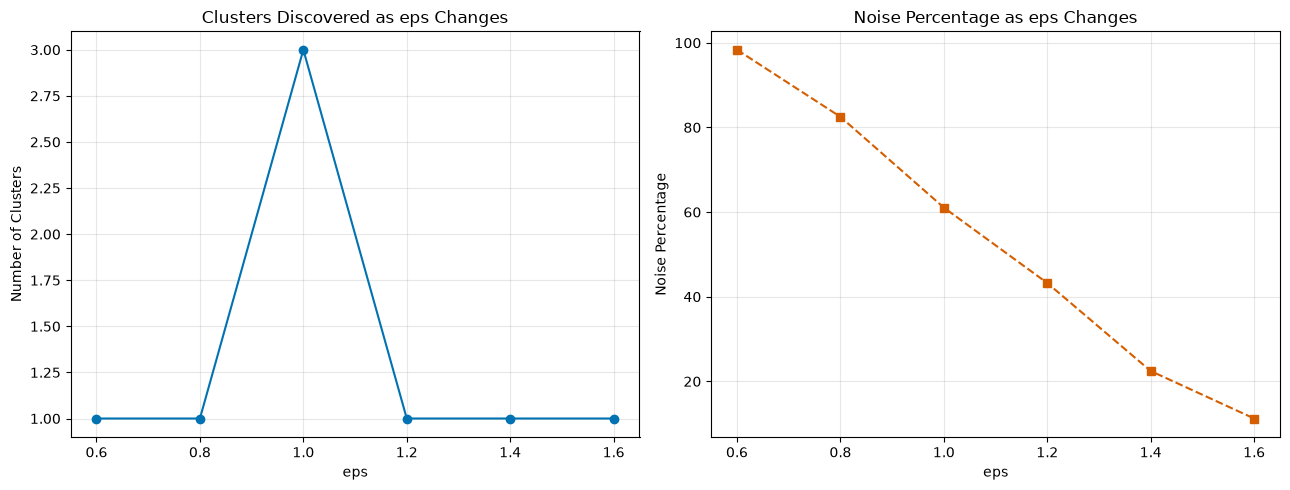

In [18]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].plot(
    transition_results_df["eps"],
    transition_results_df["clusters"],
    marker="o",
    color="#0072B2"
)

axes[0].set_xlabel("eps")
axes[0].set_ylabel("Number of Clusters")
axes[0].set_title("Clusters Discovered as eps Changes")
axes[0].grid(alpha=0.3)

axes[1].plot(
    transition_results_df["eps"],
    transition_results_df["noise_percentage"],
    marker="s",
    linestyle="--",
    color="#D55E00"
)

axes[1].set_xlabel("eps")
axes[1].set_ylabel("Noise Percentage")
axes[1].set_title("Noise Percentage as eps Changes")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
dbscan_eps_1 = DBSCAN(
    eps=1.0,
    min_samples=5
)

labels_eps_1 = dbscan_eps_1.fit_predict(X_scaled)

core_mask = np.zeros(
    len(X_scaled),
    dtype=bool
)

core_mask[
    dbscan_eps_1.core_sample_indices_
] = True

point_types = np.where(
    labels_eps_1 == -1,
    "Noise",
    np.where(core_mask, "Core", "Border")
)

cluster_type_summary = pd.crosstab(
    pd.Series(labels_eps_1, name="cluster"),
    pd.Series(point_types, name="point_type")
)

cluster_type_summary

point_type,Border,Core,Noise
cluster,,,
-1,0,0,185
0,35,66,0
1,8,5,0
2,3,1,0


<h2 style="color:#0072B2;">Inspecting Core, Border, and Noise Points</h2>

To understand the unusual cluster sizes at `eps=1.0`, the observations were classified according to their DBSCAN roles.

The result shows:

- Cluster 0 contains 66 core points and 35 border points.
- Cluster 1 contains 5 core points and 8 border points.
- Cluster 2 contains 1 core point and 3 border points.
- The remaining 185 patients are labeled as noise.

Cluster 2 therefore has a final size of four observations even though `min_samples=5`.

This is possible because `min_samples` does not directly define the minimum final cluster size. It defines the number of observations that must exist inside a point's `eps` neighborhood for that point to qualify as a core point.

A border point can fall within the neighborhoods of more than one dense region. In Scikit-learn, such a shared border point is assigned to the first cluster that reaches it during expansion. Consequently, a core point may have satisfied the five-point neighborhood requirement even though fewer than five observations ultimately receive its cluster label.

<span style="color:#009E73;"><b>Key distinction:</b></span>  
`min_samples` is a local density requirement for creating a core point, not a guaranteed minimum for the final cluster size.

<span style="color:#D55E00;"><b>Interpretation:</b></span>  
Although three clusters appeared at `eps=1.0`, the result remains weak: 185 of 303 patients were classified as noise, Cluster 2 contains only four assigned patients, and the non-noise Silhouette Score is only 0.096. These are small local density fragments rather than a convincing overall division of the patient population.

<h2 style="color:#0072B2;">Testing the Effect of min_samples</h2>

The previous experiments examined how changing `eps` affects neighborhood connectivity.

The second DBSCAN parameter, `min_samples`, controls how much local evidence is required before an observation becomes a core point.

To isolate its effect, `eps` will now remain fixed at 1.8 while testing different values of `min_samples`.

The tested values are:

- `min_samples=5`: a relatively flexible density requirement.
- `min_samples=10`: a stronger density requirement.
- `min_samples=15`: a more restrictive definition of a dense region.

As `min_samples` increases, fewer observations are expected to qualify as core points. This may increase the number of border or noise points.

<span style="color:#009E73;"><b>Experiment design:</b></span>  
Change one parameter while holding the other constant so that changes in the output can be attributed specifically to `min_samples`.

In [21]:
fixed_eps = 1.8
min_samples_values = [5, 10, 15]

min_samples_results = []

for min_samples_value in min_samples_values:
    
    dbscan = DBSCAN(
        eps=fixed_eps,
        min_samples=min_samples_value
    )
    
    labels = dbscan.fit_predict(X_scaled)
    unique_labels = set(labels)
    
    n_clusters = (
        len(unique_labels)
        - (1 if -1 in unique_labels else 0)
    )
    
    noise_mask = labels == -1
    n_noise = noise_mask.sum()
    noise_percentage = (n_noise / len(labels)) * 100
    
    core_mask = np.zeros(
        len(X_scaled),
        dtype=bool
    )
    
    core_mask[
        dbscan.core_sample_indices_
    ] = True
    
    n_core = core_mask.sum()
    n_border = np.sum(
        (labels != -1) & (~core_mask)
    )
    
    cluster_sizes = (
        pd.Series(labels[~noise_mask])
        .value_counts()
        .sort_index()
        .tolist()
    )
    
    min_samples_results.append({
        "min_samples": min_samples_value,
        "clusters": n_clusters,
        "cluster_sizes": cluster_sizes,
        "core_points": n_core,
        "border_points": n_border,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage
    })

min_samples_results_df = pd.DataFrame(
    min_samples_results
)

min_samples_results_df.round(2)

,min_samples,clusters,cluster_sizes,core_points,border_points,noise_points,noise_percentage
0,5,1,[285],261,24,18,5.94
1,10,1,[279],220,59,24,7.92
2,15,1,[273],185,88,30,9.90


In [22]:
min_samples_results_df["total_points"] = (
    min_samples_results_df["core_points"]
    + min_samples_results_df["border_points"]
    + min_samples_results_df["noise_points"]
)

min_samples_results_df[
    [
        "min_samples",
        "core_points",
        "border_points",
        "noise_points",
        "total_points"
    ]
]

,min_samples,core_points,border_points,noise_points,total_points
0,5,261,24,18,303
1,10,220,59,24,303
2,15,185,88,30,303


<h2 style="color:#0072B2;">Interpreting the Effect of min_samples</h2>

With `eps` fixed at 1.8, increasing `min_samples` made the density requirement more restrictive.

The results show that:

- At `min_samples=5`, DBSCAN identified 261 core points, 24 border points, and 18 noise points.
- At `min_samples=10`, the number of core points decreased to 220, while border points increased to 59 and noise increased to 24.
- At `min_samples=15`, only 185 patients remained core points, while border points increased to 88 and noise increased to 30.

This occurred because a larger `min_samples` value requires more neighboring observations for a patient to qualify as a core point.

Some patients changed from core points to border points because they remained connected to a dense region but no longer satisfied the stricter density requirement.

Other patients became noise because they were no longer sufficiently connected to any core region.

No additional stable clusters appeared as `min_samples` increased.

<span style="color:#009E73;"><b>Key observation:</b></span>  
Increasing `min_samples` changed the roles of individual patients, but it did not reveal multiple density-separated patient groups.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Retain `min_samples=5`. It preserves the largest number of core patients and the lowest noise count without creating small or unstable density fragments.

<h2 style="color:#0072B2;">Selecting the Final DBSCAN Configuration</h2>

The final DBSCAN configuration uses:

$$
eps = 1.8
$$

and:

$$
min\_samples = 5
$$

The value `eps=1.8` lies near the beginning of the steeper region in the 5-nearest-neighbor distance plot.

This setting produced:

- One main dense region.
- 261 core patients.
- 24 border patients.
- 18 noise patients.

Using a smaller `eps` produced excessive noise and small unstable fragments.

Increasing `eps` mainly absorbed isolated patients into the same cluster without revealing another dense region.

Increasing `min_samples` also failed to reveal additional stable clusters. Instead, it converted more patients from core points into border or noise points.

<span style="color:#D55E00;"><b>Final DBSCAN decision:</b></span>  
Use `eps=1.8` and `min_samples=5`. The result will be interpreted as one connected patient population with a small number of locally isolated observations.

In [23]:
final_dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

final_dbscan_labels = final_dbscan.fit_predict(
    X_scaled
)

final_core_mask = np.zeros(
    len(X_scaled),
    dtype=bool
)

final_core_mask[
    final_dbscan.core_sample_indices_
] = True

final_point_types = np.where(
    final_dbscan_labels == -1,
    "Noise",
    np.where(
        final_core_mask,
        "Core",
        "Border"
    )
)

final_dbscan_summary = (
    pd.Series(
        final_point_types,
        name="point_type"
    )
    .value_counts()
    .reindex(
        ["Core", "Border", "Noise"],
        fill_value=0
    )
)

final_dbscan_summary

point_type
Core      261
Border     24
Noise      18
Name: count, dtype: int64

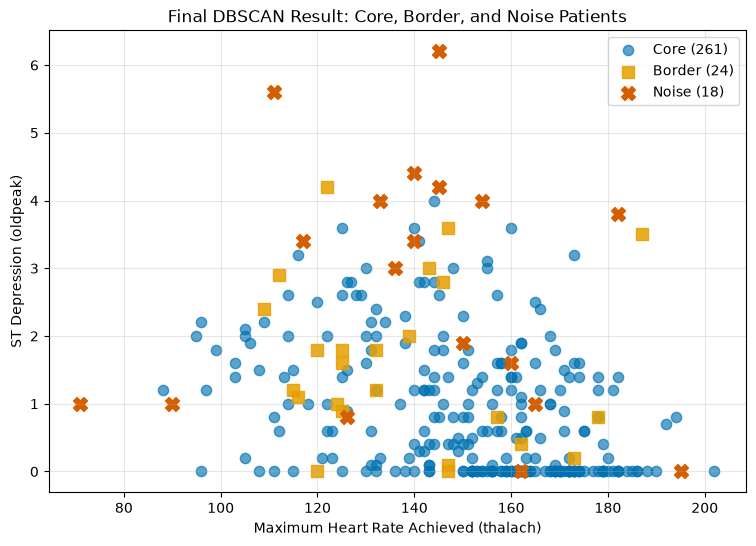

In [24]:
dbscan_plot_data = X_imputed.copy()

dbscan_plot_data["dbscan_label"] = final_dbscan_labels
dbscan_plot_data["point_type"] = final_point_types

point_styles = {
    "Core": {
        "color": "#0072B2",
        "marker": "o",
        "size": 55,
        "alpha": 0.65
    },
    "Border": {
        "color": "#E69F00",
        "marker": "s",
        "size": 65,
        "alpha": 0.85
    },
    "Noise": {
        "color": "#D55E00",
        "marker": "X",
        "size": 100,
        "alpha": 1.0
    }
}

plt.figure(figsize=(9, 6))

for point_type in ["Core", "Border", "Noise"]:

    points = dbscan_plot_data[
        dbscan_plot_data["point_type"] == point_type
    ]

    style = point_styles[point_type]

    plt.scatter(
        points["thalach"],
        points["oldpeak"],
        color=style["color"],
        marker=style["marker"],
        s=style["size"],
        alpha=style["alpha"],
        label=f"{point_type} ({len(points)})"
    )

plt.xlabel("Maximum Heart Rate Achieved (thalach)")
plt.ylabel("ST Depression (oldpeak)")
plt.title("Final DBSCAN Result: Core, Border, and Noise Patients")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h2 style="color:#0072B2;">Interpreting the Final DBSCAN Result</h2>

The final DBSCAN model did not divide the patients into multiple density-separated clusters.

Instead, it identified one connected patient population containing:

- 261 core patients in the denser part of the feature space.
- 24 border patients connected to the main dense region.
- 18 noise patients that were not sufficiently connected to that region.

This differs from the Day 1 K-Means result.

K-Means was instructed to create two clusters and therefore divided every patient between two centroids.

DBSCAN was not given a required cluster count and found that most patients belong to one continuous density structure.

The plot displays only `thalach` and `oldpeak`, while DBSCAN was fitted using all six standardized features.

Therefore, a patient that appears close to the main group in this 2D view may still be unusual across the other dimensions.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
The selected clinical measurements do not form multiple clearly separated density regions. They form one broad connected population with 18 locally isolated patients.

<span style="color:#D55E00;"><b>Important limitation:</b></span>  
A DBSCAN noise label represents unusual local density. It does not automatically indicate a data error, medical abnormality, or diagnosis.

<h2 style="color:#0072B2;">Hierarchical Clustering</h2>

K-Means and DBSCAN attempt to produce a direct clustering result, but hierarchical clustering provides a different view of the data.

Agglomerative hierarchical clustering starts by treating every patient as an independent cluster.

With 303 patients, the algorithm initially begins with:

$$
303\ clusters
$$

It then repeatedly merges the two closest clusters:

$$
303 \rightarrow 302 \rightarrow 301 \rightarrow \cdots \rightarrow 1
$$

The process continues until all patients belong to one complete hierarchy.

The result is represented using a dendrogram, which shows the order and distance at which clusters were merged.

<span style="color:#009E73;"><b>Key difference:</b></span>  
Hierarchical clustering does not immediately force the data into one fixed number of clusters. It first builds the complete nested structure, which can then be examined at different levels.

<h2 style="color:#0072B2;">Understanding the Dendrogram</h2>

A dendrogram is a tree representation of the hierarchical clustering process.

It contains:

- Leaves at the bottom representing individual patients.
- Branches representing clusters of patients.
- Horizontal connections showing when two clusters were merged.
- A vertical axis showing the distance at which each merge occurred.

A merge at a low height means that the joined clusters were relatively similar.

A merge at a high height means that the clusters were more different before they were combined.

A horizontal cut through the dendrogram determines the final number of clusters.

The number of separate branches crossed by the cut is the resulting number of clusters.

<span style="color:#009E73;"><b>Key idea:</b></span>  
The dendrogram allows the cluster count to be selected after examining the nested structure rather than specifying it before building the hierarchy.

<h2 style="color:#0072B2;">Choosing a Linkage Method</h2>

Hierarchical clustering requires a rule for measuring the distance between clusters. This rule is called the linkage method.

Common linkage methods include:

- `single`: uses the closest pair of points between two clusters.
- `complete`: uses the farthest pair of points.
- `average`: uses the average pairwise distance.
- `ward`: merges the clusters that produce the smallest increase in within-cluster variance.

Ward linkage follows an objective similar to the compactness idea used by K-Means.

At every step, it chooses the merge that causes the smallest increase in the total within-cluster variation.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Use Ward linkage because the selected features are numeric, standardized, and interpreted using Euclidean distance.

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [26]:
hierarchical_linkage = linkage(
    X_scaled,
    method="ward"
)

print(
    "Linkage matrix shape:",
    hierarchical_linkage.shape
)

Linkage matrix shape: (302, 4)


<h2 style="color:#0072B2;">Reading the Linkage Matrix</h2>

The linkage matrix stores the complete sequence of hierarchical merges.

Each row contains four values:

1. The identifier of the first merged cluster.
2. The identifier of the second merged cluster.
3. The distance at which the merge occurred.
4. The total number of original observations inside the newly formed cluster.

For 303 patients, the linkage matrix contains 302 rows because exactly 302 merges are required to build one complete hierarchy.

The final rows are especially important because they represent the largest and most distant cluster merges.

In [27]:
last_merges = pd.DataFrame(
    hierarchical_linkage[-10:],
    columns=[
        "cluster_1",
        "cluster_2",
        "merge_distance",
        "merged_size"
    ]
)

last_merges.round(3)

,cluster_1,cluster_2,merge_distance,merged_size
0,573.0,582.0,8.361,59.0
1,585.0,591.0,9.733,43.0
2,593.0,595.0,9.815,94.0
3,587.0,588.0,10.045,35.0
4,581.0,598.0,11.214,59.0
5,589.0,597.0,11.840,143.0
6,592.0,594.0,12.481,58.0
7,599.0,601.0,14.146,117.0
8,596.0,602.0,16.571,160.0
9,600.0,603.0,27.830,303.0


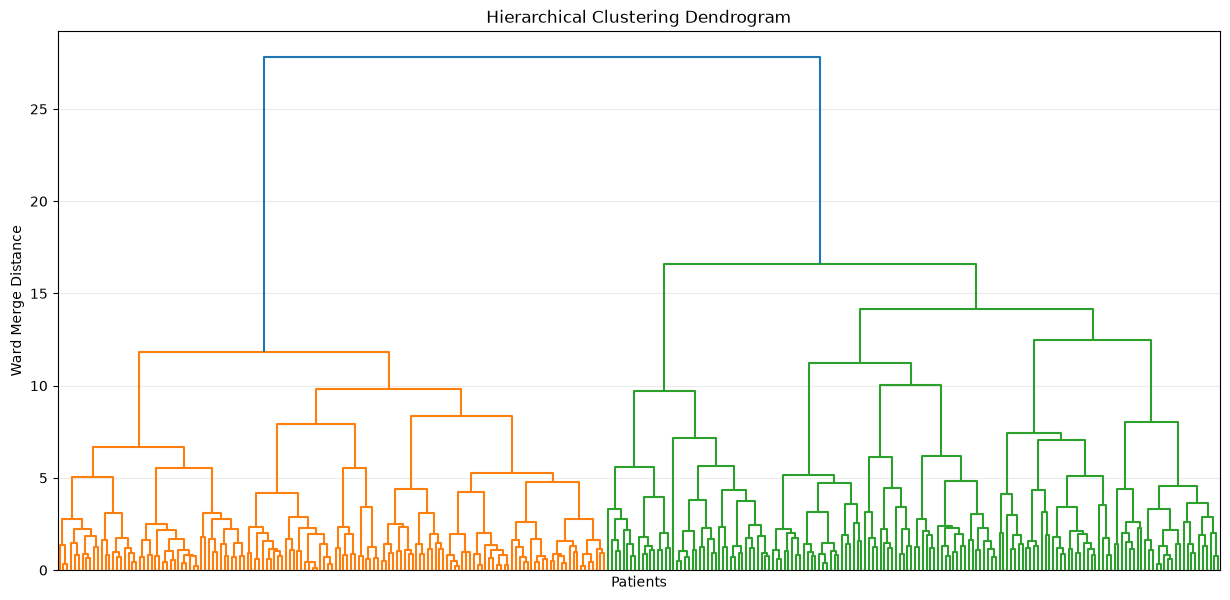

In [28]:
plt.figure(figsize=(15, 7))

dendrogram(
    hierarchical_linkage,
    no_labels=True,
    color_threshold=None
)

plt.xlabel("Patients")
plt.ylabel("Ward Merge Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.grid(
    axis="y",
    alpha=0.25
)

plt.show()

<h2 style="color:#0072B2;">Interpreting the Dendrogram</h2>

The dendrogram shows the complete nested structure produced by Ward hierarchical clustering.

Most patient groups were merged at relatively low distances, indicating that they were comparatively similar.

The final two merge distances were:

$$
16.571
$$

and:

$$
27.830
$$

The difference between them is:

$$
27.830 - 16.571 = 11.259
$$

This is a substantial jump compared with the earlier merge distances.

It means that the final two branches remained separate until a much larger increase in within-cluster variation was required to combine them.

The dendrogram therefore provides evidence for two broad hierarchical patient groups.

<span style="color:#009E73;"><b>Key observation:</b></span>  
The largest final vertical gap occurs between merge distances 16.571 and 27.830. A horizontal cut inside this gap separates the hierarchy into two main branches.

<h2 style="color:#0072B2;">Selecting the Cut Height</h2>

The cut height will be placed halfway between the last two merge distances.

$$
cut\ height =
\frac{16.571 + 27.830}{2}
$$

Therefore:

$$
cut\ height \approx 22.201
$$

This height is:

- Above the merge at 16.571, so the smaller branches below it are allowed to combine.
- Below the final merge at 27.830, so the two largest branches remain separate.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Cut the dendrogram at approximately 22.201 to obtain two broad hierarchical clusters.

In [29]:
previous_merge_distance = hierarchical_linkage[-2, 2]
final_merge_distance = hierarchical_linkage[-1, 2]

cut_height = (
    previous_merge_distance
    + final_merge_distance
) / 2

print(
    f"Previous merge distance: "
    f"{previous_merge_distance:.3f}"
)

print(
    f"Final merge distance: "
    f"{final_merge_distance:.3f}"
)

print(
    f"Selected cut height: "
    f"{cut_height:.3f}"
)

Previous merge distance: 16.571
Final merge distance: 27.830
Selected cut height: 22.201


In [32]:
from scipy.cluster.hierarchy import fcluster
hierarchical_labels = fcluster(
    hierarchical_linkage,
    t=cut_height,
    criterion="distance"
)

hierarchical_labels = (
    hierarchical_labels - 1
)

hierarchical_cluster_counts = (
    pd.Series(
        hierarchical_labels,
        name="cluster"
    )
    .value_counts()
    .sort_index()
)

print("Number of clusters:")
print(
    len(
        np.unique(
            hierarchical_labels
        )
    )
)

print("\nPatients per cluster:")
print(hierarchical_cluster_counts)

Number of clusters:
2

Patients per cluster:
cluster
0    143
1    160
Name: count, dtype: int64


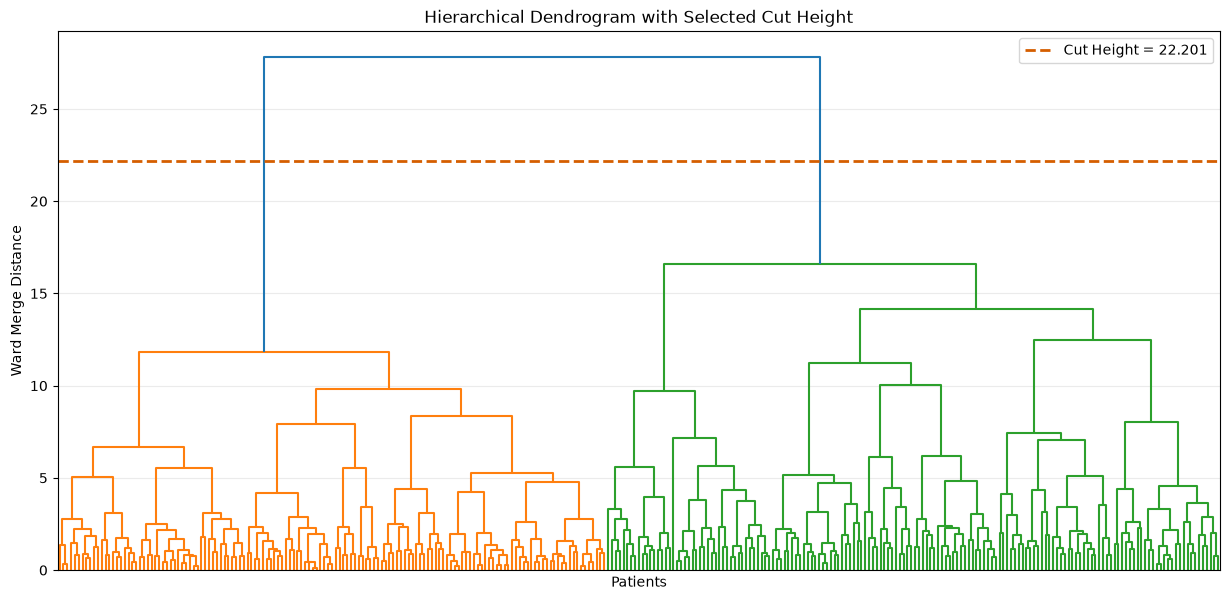

In [33]:
plt.figure(figsize=(15, 7))

dendrogram(
    hierarchical_linkage,
    no_labels=True,
    color_threshold=cut_height
)

plt.axhline(
    y=cut_height,
    color="#D55E00",
    linestyle="--",
    linewidth=2,
    label=f"Cut Height = {cut_height:.3f}"
)

plt.xlabel("Patients")
plt.ylabel("Ward Merge Distance")
plt.title(
    "Hierarchical Dendrogram with Selected Cut Height"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.25
)

plt.show()

In [34]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Silhouette Score:",
    round(
        hierarchical_silhouette,
        3
    )
)

Hierarchical Silhouette Score: 0.192


<h2 style="color:#0072B2;">Profiling the Hierarchical Clusters</h2>

The hierarchical labels only identify which patients were grouped together.

The numerical labels `0` and `1` do not have predefined meanings.

To interpret the discovered groups, the cluster averages will be calculated using the original clinical units before standardization.

This makes it possible to determine which measurements distinguish the two main branches.

<span style="color:#009E73;"><b>Key idea:</b></span>  
The standardized data is used to build the hierarchy, while the original clinical units are used to explain its result.

In [35]:
hierarchical_profile_data = (
    X_imputed.copy()
)

hierarchical_profile_data[
    "cluster"
] = hierarchical_labels

hierarchical_profiles = (
    hierarchical_profile_data
    .groupby("cluster")
    .mean()
    .round(2)
)

hierarchical_profiles

,age,trestbps,chol,thalach,oldpeak,ca
cluster,,,,,,
0,48.45,125.59,230.31,162.44,0.58,0.15
1,59.79,137.14,261.34,138.14,1.45,1.12


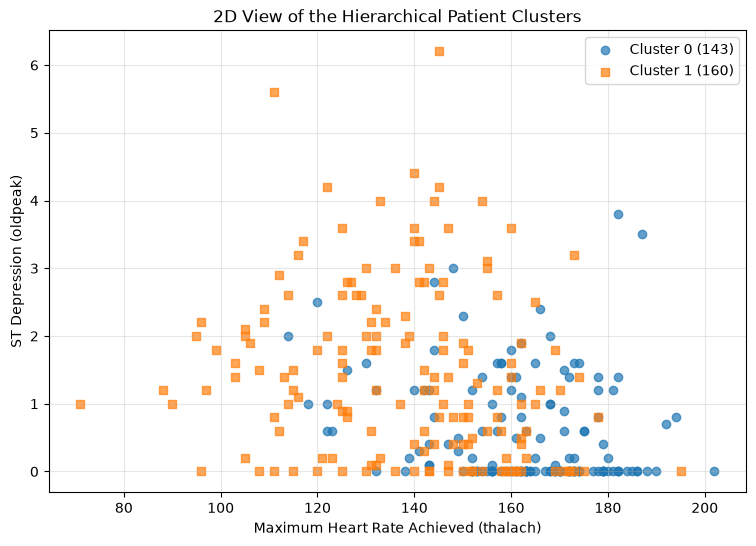

In [36]:
hierarchical_plot_data = (
    X_imputed.copy()
)

hierarchical_plot_data[
    "cluster"
] = hierarchical_labels

hierarchical_markers = {
    0: "o",
    1: "s"
}

plt.figure(figsize=(9, 6))

for cluster_id in sorted(
    hierarchical_plot_data[
        "cluster"
    ].unique()
):

    cluster_points = (
        hierarchical_plot_data[
            hierarchical_plot_data[
                "cluster"
            ] == cluster_id
        ]
    )

    plt.scatter(
        cluster_points["thalach"],
        cluster_points["oldpeak"],
        marker=hierarchical_markers[
            cluster_id
        ],
        alpha=0.7,
        label=(
            f"Cluster {cluster_id} "
            f"({len(cluster_points)})"
        )
    )

plt.xlabel(
    "Maximum Heart Rate Achieved (thalach)"
)

plt.ylabel(
    "ST Depression (oldpeak)"
)

plt.title(
    "2D View of the Hierarchical Patient Clusters"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h2 style="color:#0072B2;">Viewing All Six Hierarchical Features</h2>

The 2D scatter plot shows only one perspective of the hierarchical result.

However, Ward linkage was applied using all six standardized features.

A standardized profile plot will therefore be used to compare the average position of each hierarchical cluster across every feature used during clustering.

A value above zero means that the cluster average is above the overall dataset average for that feature.

A value below zero means that it is below the overall dataset average.

In [37]:
scaled_hierarchical_data = (
    X_scaled.copy()
)

scaled_hierarchical_data[
    "cluster"
] = hierarchical_labels

standardized_hierarchical_profiles = (
    scaled_hierarchical_data
    .groupby("cluster")
    .mean()
)

standardized_hierarchical_profiles.round(3)

,age,trestbps,chol,thalach,oldpeak,ca
cluster,,,,,,
0,-0.663,-0.347,-0.317,0.562,-0.394,-0.546
1,0.593,0.310,0.283,-0.502,0.352,0.488


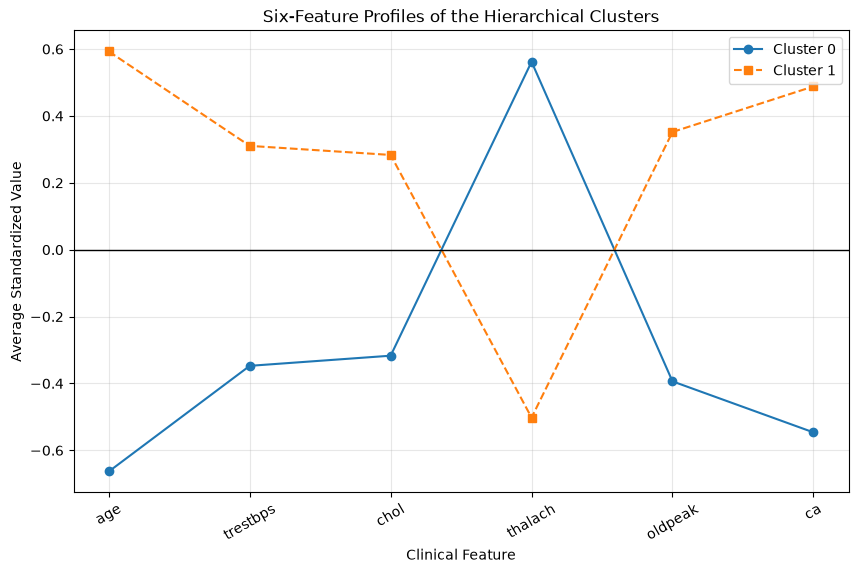

In [38]:
hierarchical_line_styles = {
    0: "-",
    1: "--"
}

plt.figure(figsize=(10, 6))

for cluster_id in (
    standardized_hierarchical_profiles.index
):

    plt.plot(
        clustering_features,
        standardized_hierarchical_profiles.loc[
            cluster_id
        ],
        marker=hierarchical_markers[
            cluster_id
        ],
        linestyle=hierarchical_line_styles[
            cluster_id
        ],
        label=f"Cluster {cluster_id}"
    )

plt.axhline(
    y=0,
    color="black",
    linewidth=1
)

plt.xlabel("Clinical Feature")

plt.ylabel(
    "Average Standardized Value"
)

plt.title(
    "Six-Feature Profiles of the Hierarchical Clusters"
)

plt.xticks(rotation=30)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h2 style="color:#0072B2;">Interpreting the Hierarchical Patient Profiles</h2>

Cutting the dendrogram at a Ward merge distance of approximately 22.201 produced two broad hierarchical clusters:

- Cluster 0 contains 143 patients.
- Cluster 1 contains 160 patients.

The cluster sizes are relatively balanced, so the result is not created by separating only a small number of unusual patients from the rest of the dataset.

### Cluster 0

Patients in Cluster 0 tend to have:

- Lower age.
- Lower resting blood pressure.
- Lower cholesterol.
- Higher maximum achieved heart rate.
- Lower exercise-related ST depression (`oldpeak`).
- Lower values of `ca`.

### Cluster 1

Patients in Cluster 1 tend to have:

- Higher age.
- Higher resting blood pressure.
- Higher cholesterol.
- Lower maximum achieved heart rate.
- Higher `oldpeak`.
- Higher values of `ca`.

The standardized profile plot shows that the separation is based on a consistent combination of all six measurements rather than one feature alone.

The 2D scatter plot still contains visible overlap because it displays only `thalach` and `oldpeak`, while Ward clustering used the complete six-dimensional standardized representation.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
Hierarchical clustering identified two broad patient profiles. One branch generally contains younger patients with higher achieved heart rates and lower values across the other selected measurements, while the second branch shows the opposite pattern.

<span style="color:#D55E00;"><b>Important limitation:</b></span>  
These hierarchical groups are statistical profiles, not diagnostic categories. The diagnosis target was not used during clustering.

<h2 style="color:#0072B2;">Comparing K-Means, DBSCAN, and Hierarchical Clustering</h2>

The three methods were applied to the same six standardized patient features, allowing their results to be compared fairly.

However, each method represents the data differently:

- K-Means divides every patient between a predefined number of centroid-based clusters.
- DBSCAN searches for density-separated regions and can explicitly label isolated observations as noise.
- Hierarchical clustering builds a nested structure and allows the number of groups to be selected by cutting the dendrogram.

The comparison will consider:

- Number of discovered clusters.
- Number of noise points.
- Cluster sizes.
- Silhouette Score when at least two clusters exist.
- The structural interpretation produced by each method.

In [39]:
comparison_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

comparison_kmeans_labels = (
    comparison_kmeans.fit_predict(
        X_scaled
    )
)

kmeans_silhouette = silhouette_score(
    X_scaled,
    comparison_kmeans_labels
)

kmeans_cluster_sizes = (
    pd.Series(
        comparison_kmeans_labels
    )
    .value_counts()
    .sort_index()
    .tolist()
)

hierarchical_cluster_sizes = (
    pd.Series(
        hierarchical_labels
    )
    .value_counts()
    .sort_index()
    .tolist()
)

dbscan_cluster_count = (
    len(
        set(
            final_dbscan_labels
        )
    )
    - (
        1
        if -1 in final_dbscan_labels
        else 0
    )
)

dbscan_cluster_sizes = (
    pd.Series(
        final_dbscan_labels[
            final_dbscan_labels != -1
        ]
    )
    .value_counts()
    .sort_index()
    .tolist()
)

dbscan_noise_count = np.sum(
    final_dbscan_labels == -1
)

In [40]:
clustering_comparison = pd.DataFrame({
    "method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "clusters": [
        2,
        dbscan_cluster_count,
        len(
            np.unique(
                hierarchical_labels
            )
        )
    ],
    "cluster_sizes": [
        kmeans_cluster_sizes,
        dbscan_cluster_sizes,
        hierarchical_cluster_sizes
    ],
    "noise_points": [
        0,
        dbscan_noise_count,
        0
    ],
    "silhouette_score": [
        kmeans_silhouette,
        np.nan,
        hierarchical_silhouette
    ]
})

clustering_comparison.round(3)

,method,clusters,cluster_sizes,noise_points,silhouette_score
0,K-Means,2,"[131, 172]",0,0.232
1,DBSCAN,1,[285],18,NaN
2,Hierarchical,2,"[143, 160]",0,0.192


In [41]:
print(
    "K-Means Silhouette Score:",
    round(
        kmeans_silhouette,
        3
    )
)

print(
    "Hierarchical Silhouette Score:",
    round(
        hierarchical_silhouette,
        3
    )
)

print(
    "DBSCAN Silhouette Score: "
    "Not applicable because only one "
    "cluster was discovered."
)

K-Means Silhouette Score: 0.232
Hierarchical Silhouette Score: 0.192
DBSCAN Silhouette Score: Not applicable because only one cluster was discovered.


<h2 style="color:#0072B2;">Interpreting the Method Comparison</h2>

The three clustering methods produced different descriptions of the same patient data.

### K-Means

K-Means divided all 303 patients into two clusters containing 131 and 172 patients.

Its Silhouette Score was:

$$
0.232
$$

This was the highest Silhouette Score among the methods that produced multiple clusters.

However, the value is still modest, indicating that the two profiles overlap and are not sharply separated.

### DBSCAN

DBSCAN identified one dense region containing 285 patients and labeled 18 patients as noise.

Because it found only one cluster, a Silhouette Score could not be calculated.

This result suggests that the data does not contain multiple clearly separated density regions under the selected parameters.

### Hierarchical Clustering

Hierarchical clustering produced two relatively balanced clusters containing 143 and 160 patients.

Its Silhouette Score was:

$$
0.192
$$

The dendrogram showed a clear final split between two broad branches, but the lower Silhouette Score indicates that these groups overlap more than the two K-Means clusters.

<span style="color:#009E73;"><b>Comparison:</b></span>  
K-Means produced the strongest complete two-group separation, DBSCAN provided the clearest noise detection, and hierarchical clustering provided the clearest view of the nested patient structure.

<h2 style="color:#0072B2;">Final Method Selection and Day 2 Conclusion</h2>

The purpose of this notebook was to determine which clustering method best represents the structure of the selected Cleveland patient measurements.

For a complete segmentation of the patients into interpretable groups, K-Means provided the best result among the tested methods.

The reasons are:

- It produced the highest Silhouette Score at 0.232.
- It created two reasonably sized patient groups.
- Its cluster profiles showed consistent differences across all six clinical measurements.
- Hierarchical clustering produced a similar broad two-profile structure but with a lower Silhouette Score of 0.192.

Therefore:

<span style="color:#D55E00;"><b>Final decision:</b></span>  
K-Means is the preferred method for dividing this dataset into broad patient profiles.

However, this decision requires caution.

A Silhouette Score of 0.232 indicates only modest separation. The data should therefore be described as containing broad and overlapping patient profiles rather than two naturally isolated populations.

DBSCAN remains valuable for a different objective. It showed that the patients form one connected density region and identified 18 locally isolated observations that K-Means was forced to assign to a cluster.

Hierarchical clustering also contributed information that K-Means could not provide. Its dendrogram revealed the nested structure and showed how smaller patient groups gradually merged into two broad branches.

### Final Takeaways

- K-Means is most suitable when a complete broad segmentation is required.
- DBSCAN is most suitable when noise detection and irregular density structure are the priority.
- Hierarchical clustering is most suitable when the nested relationships between observations need to be examined.
- The preferred method depends on the analytical objective and the observed shape of the data.
- Cluster labels are statistical groupings and must not be interpreted as diagnoses.

<span style="color:#009E73;"><b>Final lesson:</b></span>  
A clustering algorithm should not be selected because it produces more clusters or a visually attractive result. The decision should combine data shape, parameter behavior, quantitative metrics, interpretability, and the purpose of the analysis.